In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [7]:
df = pd.read_csv(r"C:\Users\Dell\Data_Science\Data\IPL_DataSet.csv")

In [15]:
df

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0


In [17]:
df.isnull().sum()

Jersey No        0
Player           0
Matches          0
Inns             0
Not Out          0
Runs             0
Highest Score    0
Avg              0
Balls faced      0
Strike rate      0
100              0
50               0
4s               0
6s               0
dtype: int64

In [19]:
df.info

<bound method DataFrame.info of      Jersey No             Player  Matches  Inns  Not Out  Runs Highest Score  \
0            1           KL Rahul       14    14        2   670          132*   
1            2     Shikhar Dhawan       17    17        3   618          106*   
2            3       David Warner       16    16        2   548           85*   
3            4       Shreyas Iyer       17    17        2   519           88*   
4            5       Ishan Kishan       14    13        4   516            99   
..         ...                ...      ...   ...      ...   ...           ...   
128        129      Khaleel Ahmed        7     1        0     0            0*   
129        130     Arshdeep Singh        8     1        0     0            0*   
130        131        Daniel Sams        3     1        0     0            0*   
131        132  Shreevats Goswami        2     2        0     0            0*   
132        133        Trent Boult       15     1        0     0            0*

In [21]:
df.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


In [23]:
df.tail()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
128,129,Khaleel Ahmed,7,1,0,0,0*,0.0,2,0.0,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.0,3,0.0,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.0,2,0.0,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.0,4,0.0,0,0,0,0
132,133,Trent Boult,15,1,0,0,0*,0.0,1,0.0,0,0,0,0


In [25]:
df.columns

Index(['Jersey No', 'Player', 'Matches', 'Inns', 'Not Out', 'Runs',
       'Highest Score', 'Avg', 'Balls faced', 'Strike rate', '100', '50', '4s',
       '6s'],
      dtype='object')

In [ ]:
# 1. What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.

In [32]:
max_match_by_player = df.groupby("Player")["Matches"].max()
max_match_by_player

Player
ABD Villiers         15
Aaron Finch          12
Abdul Samad          12
Abhishek Sharma       8
Ajinkya Rahane        9
                     ..
Virat Kohli          15
Washington Sundar    15
Wriddhiman Saha       4
Yashasvi Jaiswal      3
Yuzvendra Chahal     15
Name: Matches, Length: 133, dtype: int64

In [38]:
# Q1: Maximum number of matches played by an individual player in a season
max_matches = df.loc[df["Matches"].idxmax(), ["Player", "Matches"]]
max_matches


Player     Shikhar Dhawan
Matches                17
Name: 1, dtype: object

In [40]:
# Q2: Top 2 players with maximum Average who have scored at least 2 half-centuries
top_avg_players = df[df["50"] >= 2].nlargest(2, "Avg")[["Player", "Avg"]]
top_avg_players


,Player,Avg
36,Wriddhiman Saha,71.33
4,Ishan Kishan,57.33


In [42]:
# Q3: Create First Name and Last Name columns
df["First Name"] = df["Player"].apply(lambda x: x.split()[0])
df["Last Name"] = df["Player"].apply(lambda x: " ".join(x.split()[1:]) if len(x.split()) > 1 else "")
df[["Player", "First Name", "Last Name"]].head()


,Player,First Name,Last Name
0,KL Rahul,KL,Rahul
1,Shikhar Dhawan,Shikhar,Dhawan
2,David Warner,David,Warner
3,Shreyas Iyer,Shreyas,Iyer
4,Ishan Kishan,Ishan,Kishan


In [44]:
# Q4: Create a new column 'Cleaned_Highest_Score' by removing asterisks and converting to integer
df["Cleaned_Highest_Score"] = df["Highest Score"].str.replace('*', '', regex=False).astype(int)
df[["Player", "Highest Score", "Cleaned_Highest_Score"]].head()


,Player,Highest Score,Cleaned_Highest_Score
0,KL Rahul,132*,132
1,Shikhar Dhawan,106*,106
2,David Warner,85*,85
3,Shreyas Iyer,88*,88
4,Ishan Kishan,99,99


In [46]:
# Q4: Create a new column 'Cleaned_Highest_Score' by removing asterisks and converting to integer
df["Cleaned_Highest_Score"] = df["Highest Score"].str.replace('*', '', regex=False).astype(int)
df[["Player", "Highest Score", "Cleaned_Highest_Score"]].head()


,Player,Highest Score,Cleaned_Highest_Score
0,KL Rahul,132*,132
1,Shikhar Dhawan,106*,106
2,David Warner,85*,85
3,Shreyas Iyer,88*,88
4,Ishan Kishan,99,99


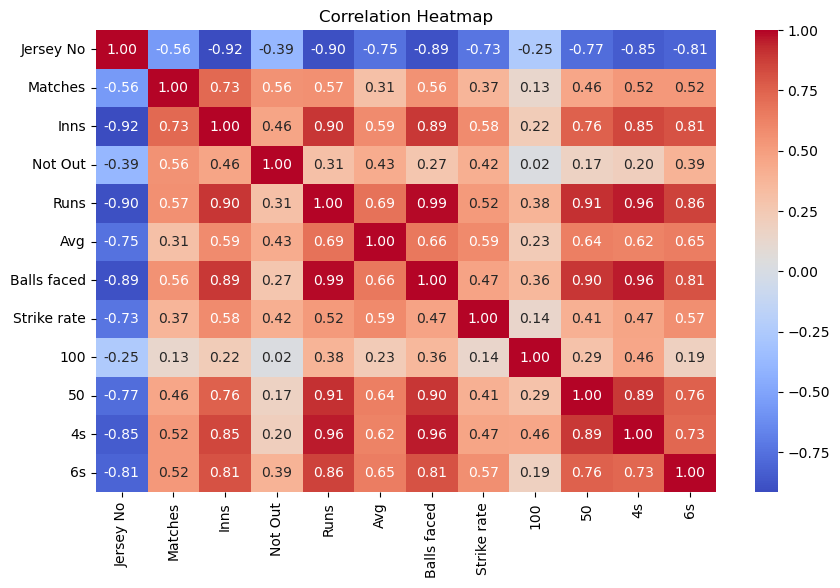

In [48]:
# Q7: Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [50]:
# Q8: Players with average > 50 and strike rate > 120
top_performers = df[(df["Avg"] > 50) & (df["Strike rate"] > 120)][["Player", "Avg", "Strike rate"]]
top_performers



,Player,Avg,Strike rate
0,KL Rahul,55.83,129.34
4,Ishan Kishan,57.33,145.76
31,Kieron Pollard,53.60,191.42
36,Wriddhiman Saha,71.33,139.86
37,Ruturaj Gaikwad,51.00,120.71
57,Deepak Hooda,101.00,142.25
60,Tom Curran,83.00,133.87


In [52]:
# Q9: Players with average > 40 and balls faced > 100
consistent_batsmen = df[(df["Avg"] > 40) & (df["Balls faced"] > 100)][["Player", "Avg", "Balls faced"]]
consistent_batsmen


,Player,Avg,Balls faced
0,KL Rahul,55.83,518
1,Shikhar Dhawan,44.14,427
4,Ishan Kishan,57.33,354
8,Virat Kohli,42.36,384
9,ABD Villiers,45.40,286
10,Faf Duplessis,40.81,319
14,Eoin Morgan,41.80,302
24,Kane Williamson,45.28,237
27,Chris Gayle,41.14,210
28,Ben Stokes,40.71,200


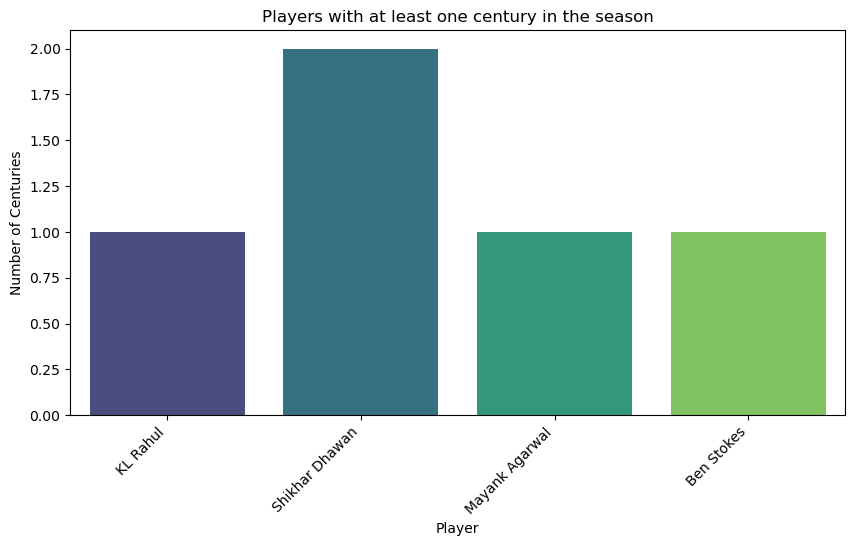

In [54]:
# Q10: Players who scored at least one century in the season - Visualization
century_scorers = df[df["100"] >= 1][["Player", "100"]]

# Bar plot for players with at least one century
plt.figure(figsize=(10, 5))
sns.barplot(x="Player", y="100", data=century_scorers, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Player")
plt.ylabel("Number of Centuries")
plt.title("Players with at least one century in the season")
plt.show()


In [56]:
# Q11: Players who scored at least 4 half-centuries
half_century_scorers = df[df["50"] >= 4][["Player", "50"]]
half_century_scorers


,Player,50
0,KL Rahul,5
1,Shikhar Dhawan,4
2,David Warner,4
4,Ishan Kishan,4
5,Quinton Kock,4
6,Suryakumar Yadav,4
7,Devdutt Padikkal,5
9,ABD Villiers,5
10,Faf Duplessis,4


In [58]:
# Q12: Players who hit more than 45 boundaries and more than 10 sixes
boundary_six_hitters = df[(df["4s"] > 45) & (df["6s"] > 10)][["Player", "4s", "6s"]]
boundary_six_hitters


,Player,4s,6s
0,KL Rahul,58,23
1,Shikhar Dhawan,67,12
2,David Warner,52,14
5,Quinton Kock,46,22
6,Suryakumar Yadav,61,11


<Figure size 800x500 with 0 Axes>

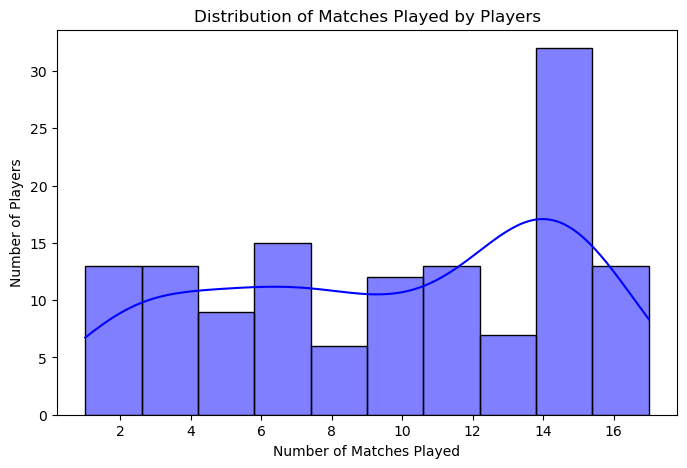

In [62]:
# Q13: Histogram of number of matches played by players
plt.figure(figsize=(8, 5))
sns.histplot(df["Matches"], bins=10, kde=True, color="blue")
plt.xlabel("Number of Matches Played")
plt.ylabel("Number of Players")
plt.title("Distribution of Matches Played by Players")
plt.show()


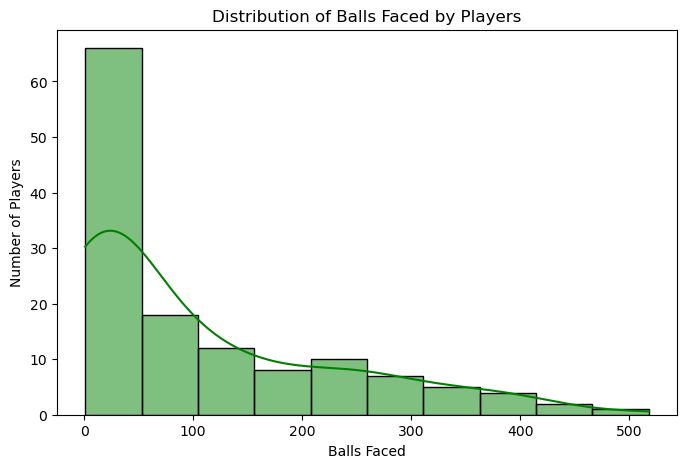

In [64]:
# Q14: Histogram of balls faced by players
plt.figure(figsize=(8, 5))
sns.histplot(df["Balls faced"], bins=10, kde=True, color="green")
plt.xlabel("Balls Faced")
plt.ylabel("Number of Players")
plt.title("Distribution of Balls Faced by Players")
plt.show()


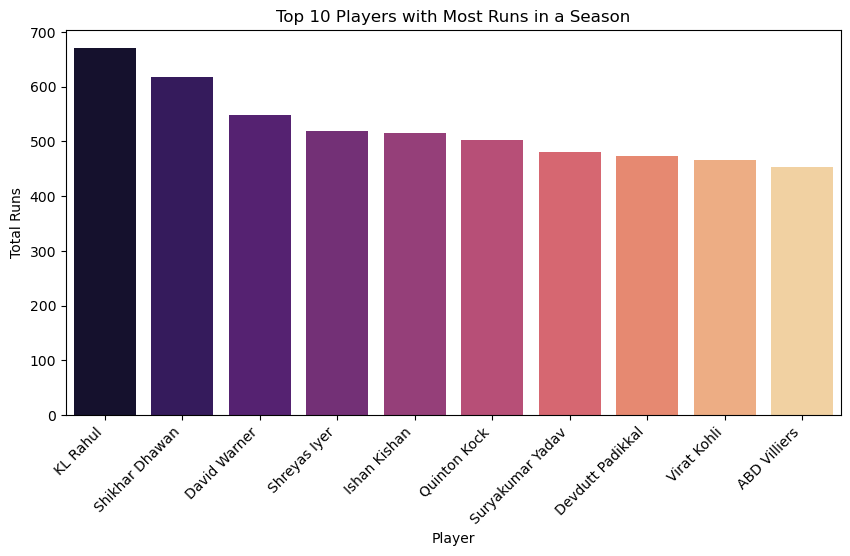

,Player,Runs
0,KL Rahul,670
1,Shikhar Dhawan,618
2,David Warner,548
3,Shreyas Iyer,519
4,Ishan Kishan,516
5,Quinton Kock,503
6,Suryakumar Yadav,480
7,Devdutt Padikkal,473
8,Virat Kohli,466
9,ABD Villiers,454


In [66]:
# Q15: Top 10 players with most runs in a season
top_run_scorers = df.nlargest(10, "Runs")[["Player", "Runs"]]

# Bar plot of top 10 run-scorers
plt.figure(figsize=(10, 5))
sns.barplot(x="Player", y="Runs", data=top_run_scorers, palette="magma")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.title("Top 10 Players with Most Runs in a Season")
plt.show()

top_run_scorers


In [68]:
# Q16: Players who played the match but didn't get to bat
players_no_batting = df[df["Inns"] == 0][["Player", "Matches", "Inns"]]
players_no_batting


,Player,Matches,Inns


In [70]:
# Q17: Create a new column for the percentage of runs scored in 4s and 6s
df["Boundary_Percentage"] = ((df["4s"] * 4 + df["6s"] * 6) / df["Runs"]) * 100

# Top 5 players with maximum boundary percentage
top_boundary_players = df.nlargest(5, "Boundary_Percentage")[["Player", "Boundary_Percentage"]]
top_boundary_players


,Player,Boundary_Percentage
109,Andrew Tye,100.000000
48,Andre Russell,76.923077
74,Chris Morris,76.470588
29,Hardik Pandya,73.309609
47,Sunil Narine,72.727273


In [72]:
# Q18: Players with top 5 Not Out percentages (Not Outs / Innings)
df["Not Out Percentage"] = (df["Not Out"] / df["Inns"]) * 100

# Top 5 players with highest Not Out percentage
top_not_out_players = df.nlargest(5, "Not Out Percentage")[["Player", "Not Out Percentage"]]
top_not_out_players


,Player,Not Out Percentage
62,Gurkeerat Singh,100.0
68,Lockie Ferguson,100.0
93,Imran Tahir,100.0
97,Mohammad Nabi,100.0
105,Pravin Dubey,100.0


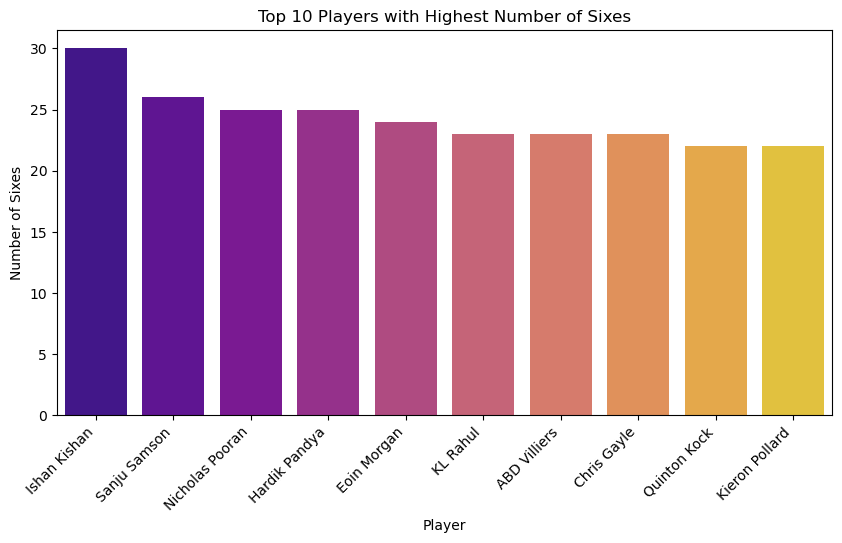

In [74]:
# Q19: Visualization of top 10 players with highest number of sixes
top_six_hitters = df.nlargest(10, "6s")[["Player", "6s"]]

# Bar plot for top 10 six hitters
plt.figure(figsize=(10, 5))
sns.barplot(x="Player", y="6s", data=top_six_hitters, palette="plasma")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Player")
plt.ylabel("Number of Sixes")
plt.title("Top 10 Players with Highest Number of Sixes")
plt.show()


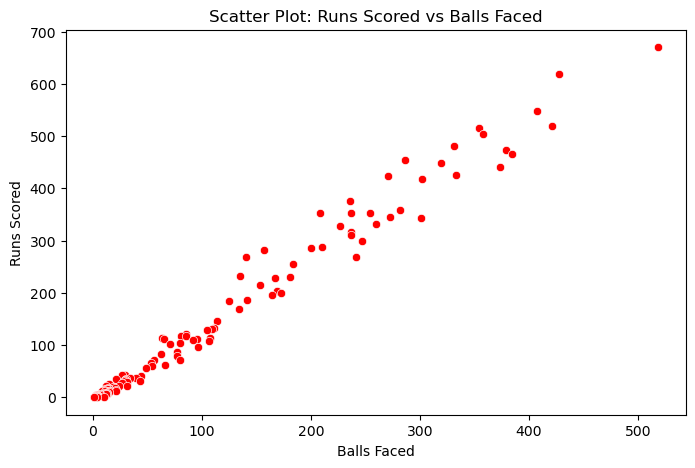

0.9899480233860845

In [76]:
# Q20: Scatter plot of runs scored vs balls faced and relationship analysis
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Balls faced"], y=df["Runs"], color="red")
plt.xlabel("Balls Faced")
plt.ylabel("Runs Scored")
plt.title("Scatter Plot: Runs Scored vs Balls Faced")

# Checking the correlation between Runs and Balls Faced
correlation = df["Runs"].corr(df["Balls faced"])
plt.show()

correlation
